In [15]:
# Install required libraries (if not installed)
!pip install pandas google-play-scraper

# Import necessary libraries
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

In [16]:

# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.ea.game.pvzfree_row"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.ea.game.pvzfree_row


In [17]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='en',   # Language: English
    country='us',  # Country: US
    count=200,   # Fetch 200 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8bec0513-2d7a-44fd-abe3-cafc5e763c4d,Angela Rubin,https://play-lh.googleusercontent.com/a/ACg8oc...,best tower defense game out there,5,0,None,2026-03-29 03:24:17,None,None,None
1,af2996d0-5414-4df9-861e-58003850f174,Bijendra Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,bessssstttttttttttt game ever! !!!!!!!!!!!,5,0,3.15.0,2026-03-29 03:06:38,None,None,3.15.0
2,1ce50f79-97d2-41d3-87e1-28a40ab6fb62,Aaron Miles,https://play-lh.googleusercontent.com/a-/ALV-U...,I use to love this game but you have ruined it...,1,0,3.15.0,2026-03-29 01:21:59,None,None,3.15.0
3,32e72aa2-ad9f-4520-99b5-799409c4304d,Rana Singh,https://play-lh.googleusercontent.com/a/ACg8oc...,wow,5,0,None,2026-03-29 01:20:11,None,None,None
4,25668f79-6649-42a5-aa8b-8c617b529439,mu gsh,https://play-lh.googleusercontent.com/a-/ALV-U...,烦人的广告播放按钮，我花钱买过了的！ 成就列表不支持重置，我想再玩一遍。外出没网半天打不开…,1,0,3.15.0,2026-03-29 00:53:12,None,None,3.15.0
...,...,...,...,...,...,...,...,...,...,...,...
195,a7f95c7d-b32e-4c71-931f-438cce79864a,Charu,https://play-lh.googleusercontent.com/a/ACg8oc...,Great game with very creative electric art gam...,4,3,3.14.0,2026-03-16 13:53:06,None,None,3.14.0
196,d9f5a588-cf0f-458b-9c6f-02981126a807,Gol Dol,https://play-lh.googleusercontent.com/a/ACg8oc...,this is a game of statigic pls download this t...,5,0,3.14.0,2026-03-16 13:20:40,None,None,3.14.0
197,f93866eb-74ab-4997-8a40-943dfb3dae11,Eryo Mendowza,https://play-lh.googleusercontent.com/a/ACg8oc...,scary but fun,5,0,3.14.0,2026-03-16 13:17:26,None,None,3.14.0
198,98da5c63-4249-44a0-8fdb-d6d8c7bf0b1c,James Hartley,https://play-lh.googleusercontent.com/a/ACg8oc...,"way too many ads. play for a minute, watch ads...",2,0,None,2026-03-16 10:45:35,None,None,None


In [18]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,8bec0513-2d7a-44fd-abe3-cafc5e763c4d,best tower defense game out there,5
1,af2996d0-5414-4df9-861e-58003850f174,bessssstttttttttttt game ever! !!!!!!!!!!!,5
2,1ce50f79-97d2-41d3-87e1-28a40ab6fb62,I use to love this game but you have ruined it...,1
3,32e72aa2-ad9f-4520-99b5-799409c4304d,wow,5
4,25668f79-6649-42a5-aa8b-8c617b529439,烦人的广告播放按钮，我花钱买过了的！ 成就列表不支持重置，我想再玩一遍。外出没网半天打不开…,1
...,...,...,...
195,a7f95c7d-b32e-4c71-931f-438cce79864a,Great game with very creative electric art gam...,4
196,d9f5a588-cf0f-458b-9c6f-02981126a807,this is a game of statigic pls download this t...,5
197,f93866eb-74ab-4997-8a40-943dfb3dae11,scary but fun,5
198,98da5c63-4249-44a0-8fdb-d6d8c7bf0b1c,"way too many ads. play for a minute, watch ads...",2


In [19]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Inggris
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,content,cleaned_text
0,best tower defense game out there,best tower defense game
1,bessssstttttttttttt game ever! !!!!!!!!!!!,bessssstttttttttttt game ever
2,I use to love this game but you have ruined it...,use love game ruined amount pointless ad every...
3,wow,wow
4,烦人的广告播放按钮，我花钱买过了的！ 成就列表不支持重置，我想再玩一遍。外出没网半天打不开…,烦人的广告播放按钮我花钱买过了的 成就列表不支持重置我想再玩一遍外出没网半天打不开
5,one of the best og game,one best og game
6,Too many ads. You get an ad for almost everyth...,many ad get ad almost everything sometimes ad ...
7,Best game!!!!! Total Nostalgia 🥰🥰🥰 well done c...,best game total nostalgia well done creator
8,my childhood memory,childhood memory
9,love everything except the survival aspect. no...,love everything except survival aspect chance ...


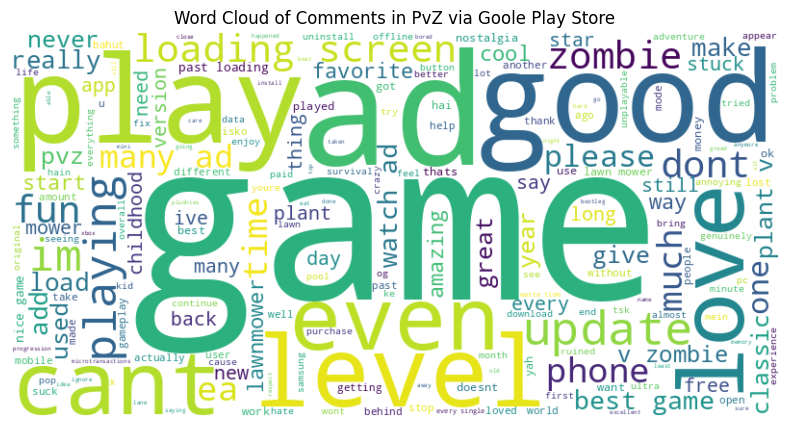

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in PvZ via Goole Play Store")
plt.show()

        Word  Frequency
3       game        161
11        ad         76
93      good         34
29       get         32
15      play         32
59    zombie         21
13     level         20
90   loading         18
7       love         17
28      many         17
195   update         16
161     even         16
46      cant         16
0       best         15
91    screen         15
17        im         14
110  playing         14
315     time         14
57     plant         14
68       fun         13


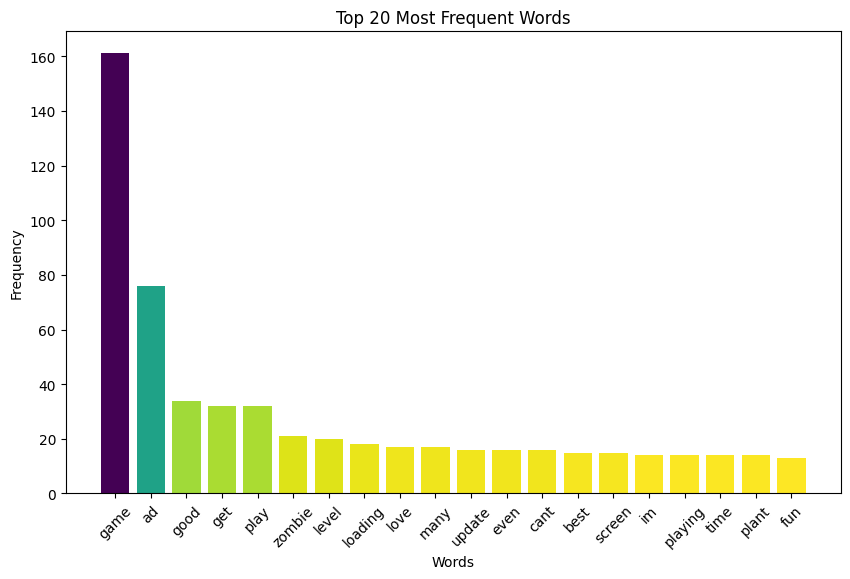

In [21]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(200, 720)


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (200, 786)
Dimensi target y: (200,)


In [24]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 160
Jumlah data testing: 40


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression()

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 85.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.71      0.83        21
    Positive       0.76      1.00      0.86        19

    accuracy                           0.85        40
   macro avg       0.88      0.86      0.85        40
weighted avg       0.89      0.85      0.85        40



In [26]:
def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "This game is a childhood masterpiece, completely love it!"
test_sentence_2 = "Too many ads and it keeps crashing on my phone. Unplayable."

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'This game is a childhood masterpiece, completely love it!'
Prediksi: Positive

Review: 'Too many ads and it keeps crashing on my phone. Unplayable.'
Prediksi: Negative


In [27]:
# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,best tower defense game out there,5,Positive
1,bessssstttttttttttt game ever! !!!!!!!!!!!,5,Positive
2,I use to love this game but you have ruined it...,1,Negative
3,wow,5,Positive
4,烦人的广告播放按钮，我花钱买过了的！ 成就列表不支持重置，我想再玩一遍。外出没网半天打不开…,1,Negative


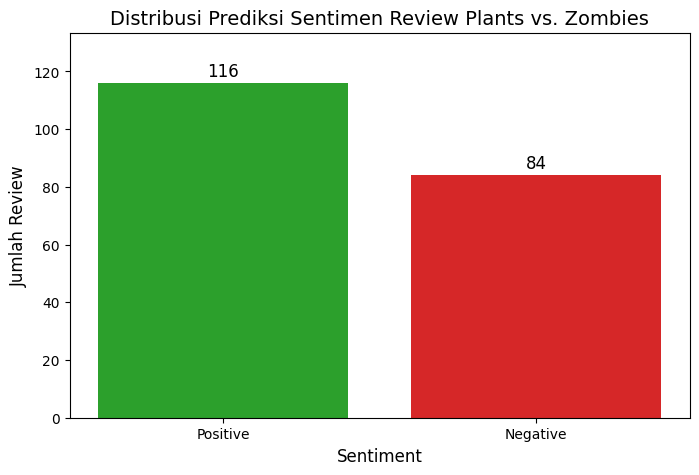

In [28]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2ca02c', '#d62728']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Plants vs. Zombies', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()